## Knickpoints vs Elevación

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import geopandas as gpd
import rasterio

In [2]:
kick10=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Knickpoints_100m_10km2/Knicpoints2_100m.shp")

In [10]:
kick5=gpd.read_file("G:\My Drive\INVESTIGACION\POSDOC\Data\Vector\Knickpoints_100m_5km2/Knicpoints_100m_5000.shp")

In [16]:
relict=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_chi.gpkg")
recent_elev=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent2_elev.gpkg")

In [12]:
dem=rasterio.open("G:\My Drive\INVESTIGACION\POSDOC\Data\Raster/DEM_30m_recortado.tif")
dem_array = dem.read(1).astype('float64')
dem_clean=np.where(dem_array<0,np.nan,dem_array)
dem_fla=dem_clean.flatten()
dem_s=pd.Series(dem_fla)

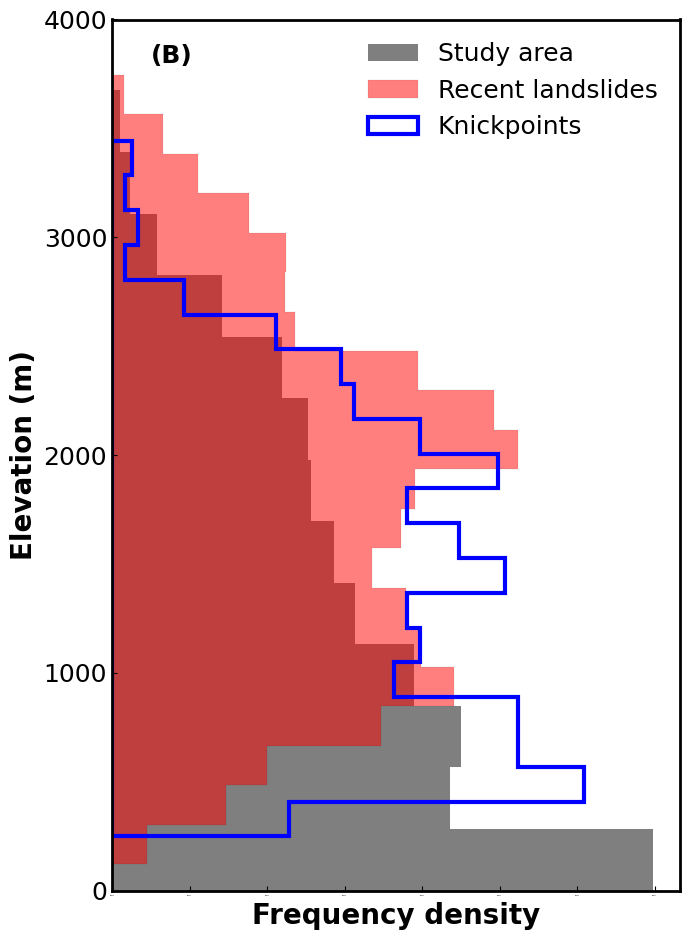

In [13]:
fig, ax = plt.subplots(figsize = (7,9.5))
#l=pd.concat([relict["elevation"],recent["elevation"]])
dem_s.hist(orientation='horizontal',histtype='stepfilled',label="Study area",bins=20,density=True,fill=True,color="black",alpha=0.5)
recent_elev["elevation1"].hist(orientation='horizontal',histtype='stepfilled',label="Recent landslides",bins=20,density=True,fill=True,color="red",alpha=0.5,linewidth=0.1,edgecolor="black")
kick5["z"].hist(orientation='horizontal',histtype='stepfilled',label="Knickpoints",bins=20,density=True,fill=False,linewidth=3,edgecolor="Blue")
plt.grid(False)
ax.set_ylabel('Elevation (m)',fontsize=20,fontweight='bold')
ax.set_xlabel('Frequency density',fontsize=20,fontweight='bold')
ax.legend(ncol=1, loc='upper right',prop={'size':18},frameon=False)
ax.set_ylim(0,4000)
ax.set_yticks([0,1000,2000,3000,4000])
ax.tick_params(axis='y', direction='in',labelsize=14)
ax.tick_params(axis='x', direction='in',labelsize=12)
ax.xaxis.set_tick_params(labelsize=0)
ax.yaxis.set_tick_params(labelsize=18)
ax.spines[['right', 'top','left','bottom']].set_linewidth(2)
fig.tight_layout() 
ax.text(0.00005,3800,"(B)",fontsize=18,weight='bold')
plt.savefig('G:/My Drive/INVESTIGACION/POSDOC/Figuras/recentVSknickpoints.png',dpi=500,transparent=True)

In [20]:
kick=gpd.read_file("G:\My Drive\INVESTIGACION\POSDOC\Data\Vector\Knickpoints_100m_5km2/kinckpoints_chi.shp")
recent_chi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent2_chi.gpkg")

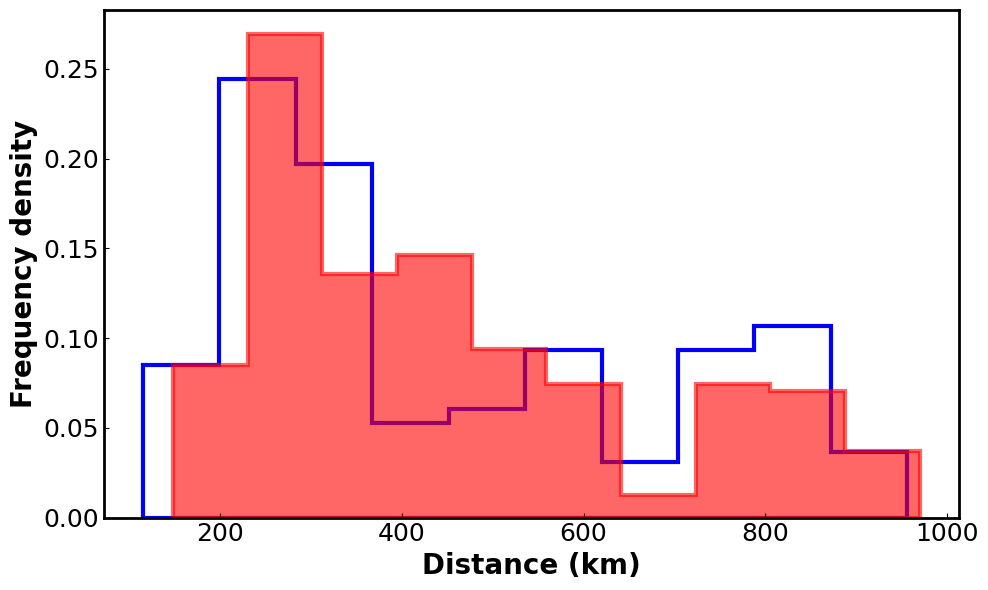

In [106]:
fig, ax = plt.subplots(figsize = (10,6))
#l=pd.concat([relict["elevation"],recent["elevation"]])
ax.hist(kick["flow_dista"]/1000,histtype='stepfilled',fill=False,linewidth=3,edgecolor="Blue",weights=1*np.full(len(kick["flow_dista"]), 1/len(kick["flow_dista"])))
ax.hist(recent_chi.flow_dista/1000,color='red',linewidth=3,edgecolor="red",histtype='stepfilled',alpha=0.6,weights=1*np.full(len(recent_chi.flow_dista), 1/len(recent_chi.flow_dista)))

plt.grid(False)
ax.set_ylabel('Frequency density',fontsize=20,fontweight='bold')
ax.set_xlabel('Distance (km)',fontsize=20,fontweight='bold')
#ax.legend(ncol=1, loc='upper right',prop={'size':18},frameon=False)
#ax.set_ylim(0,4000)
#ax.set_yticks([0,1000,2000,3000,4000])
ax.tick_params(axis='y', direction='in',labelsize=14)
ax.tick_params(axis='x', direction='in',labelsize=12)
ax.xaxis.set_tick_params(labelsize=18)
ax.yaxis.set_tick_params(labelsize=18)
ax.spines[['right', 'top','left','bottom']].set_linewidth(2)
fig.tight_layout() 
#ax.text(0.00005,3800,"(B)",fontsize=18,weight='bold')
#plt.savefig('G:/My Drive/INVESTIGACION/POSDOC/Figuras/recentVSknickpoints_distance.png',dpi=500,transparent=True)

In [264]:
bind=np.arange(0,1200000,20000)
kick['bins_dist'] = pd.cut(kick['flow_dista'],bins=bind,labels=bind[1:])
recent_chi['bins_dist'] = pd.cut(recent_chi['flow_dista'],bins=bind,labels=bind[1:])

In [252]:
bine=np.arange(0,4000,100)
kick['bins_elev'] = pd.cut(kick['z'],bins=bine,labels=bine[1:])
recent_chi['bins_elev'] = pd.cut(recent_chi['elevation'],bins=bine,labels=bine[1:])

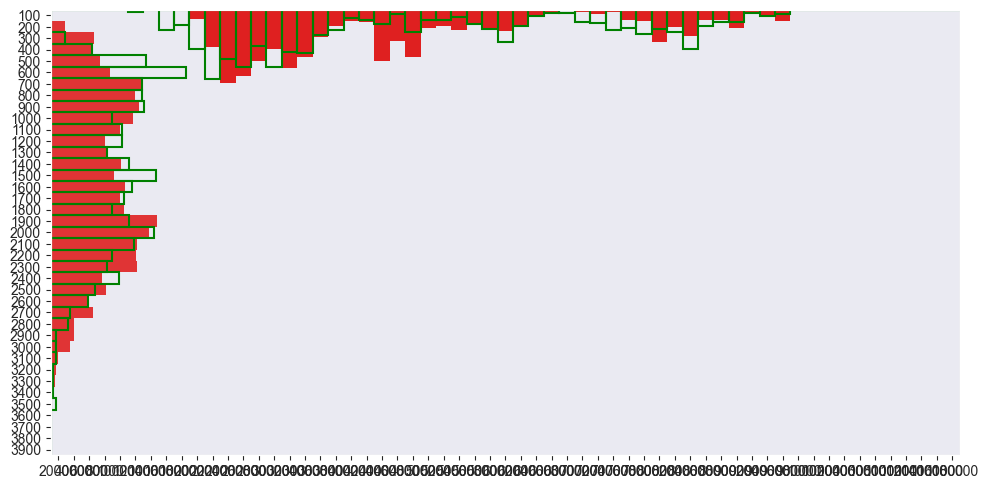

In [288]:
import seaborn as sns
fig, ax = plt.subplots(figsize = (10,5))

ax2=ax.twiny()
sns.barplot(y=bine[1:],x=200*recent_chi.groupby('bins_elev').size()/recent_chi.groupby('bins_elev').size().sum(),orient='h',ax=ax2,width=1,color="red",alpha=0.9,linewidth=0, edgecolor=".5",)
sns.barplot(y=bine[1:],x=200*kick.groupby('bins_elev').size()/kick.groupby('bins_elev').size().sum(),orient = 'h',ax=ax2,width=1,fill=False,linewidth=1.5, edgecolor="green",)

ax1=ax.twinx()
ax1=sns.barplot(x=bind[1:],y=200*recent_chi.groupby('bins_dist').size()/recent_chi.groupby('bins_dist').size().sum(),width=1,color="red",linewidth=0, edgecolor=".5",)
ax1=sns.barplot(x=bind[1:],y=200*kick.groupby('bins_dist').size()/kick.groupby('bins_dist').size().sum(),width=1,fill=False,linewidth=1.5, edgecolor="green",)


#ax.set_yticks([]) #left
#ax.set_xticks([]) #bottom
ax1.set_yticks([]) #right
#ax1.set_xticks([]) #bottom
#ax2.set_yticks([]) #left
ax2.set_xticks([]) #upper

ax1.set_ylabel('')
ax2.set_xlabel('')

ax1.set_ylim(0,100)
ax2.set_xlim(0,100)
#ax1.legend(loc='upper left',frameon=False,fontsize=16)



ax1.invert_yaxis()
fig.tight_layout() 
#plt.savefig('G:/My Drive/INVESTIGACION/POSDOC/Figuras/knickpoint_recent_full.png',dpi=500,transparent=True)